### Introduction to the two-body problem

#### Physical setup

Two bodies are far enough away from outside sources of mechanical energy that we can consider them to be isolated. Binary star systems can often be approximated this way. Likewise, analytical solutions to the Schrodinger wave equation for a hydrogen atom rely on the assumption that the proton and electron are not subject to outside influences. The potential energy of the system is determined by a central force, such as gravity or the Coulomb force. For the binary star system, 

#### $U = \frac{G m_1 m_2}{|\vec{r}_1 - \vec{r}_2|}$,

where $m_1$ and $m_2$ are the masses of the two stars and $\vec{r}_1$ and $\vec{r}_2$ are the stars' positions with respect to a fixed origin. For the hydrogen atom,

#### $U = \frac{-e^2}{4 \pi \epsilon_0 |\vec{r}_1 - \vec{r}_2|}.$

$U(\vec{r}_1, \vec{r}_2)$ is translationally independent, so that it depends only on the difference $|\vec{r}_1 - \vec{r}_2|$ and not on the individual values of either $\vec{r}_1$ or $\vec{r}_2$. $U(|\vec{r}_1 - \vec{r}_2|)$ is also independent of the direction of $\vec{r}_1 - \vec{r}_2$.

Since the exact values of $\vec{r}_1$ and $\vec{r}_2$ don't matter, we can make our lives easier by writing the potential energy in terms of their difference:

#### $\vec{r} = \vec{r}_1 - \vec{r}_2$, &emsp; $U = \frac{G m_1 m_2}{r}.$

The center of mass of the system will lie on $\vec{r}$ at

#### $\vec{R} = \frac{m_1 \vec{r}_1 + m_2 \vec{r}_2}{m_1 + m_2}.$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':16, 'axes.labelsize':16})

In [10]:
'''Code to specify star orbits in center of mass frame'''
atot = 10 # semimajor axis of large ellipse
e = 0.6 # eccentricity
m1 = 2 # star 1 mass in arbitrary units
m2 = 3 # star 2 mass
mtot = m1 + m2 # total mass
a1 = atot * m2/mtot # semimajor axis of orbit 1, mass 1
a2 = atot * m1/mtot # semimajor axis of orbit 2, mass 2

# Calculate (x1, y1) and (x2, y2) for a given f (true anomaly)
def coords(f):
    factor = (1-e**2) / (1 + e*np.cos(f))
    x1 = a1 * factor * np.cos(f)
    y1 = a1 * factor * np.sin(f)
    x2 = -a2 * factor * np.cos(f)
    y2 = -a2 * factor * np.sin(f)
    return x1, y1, x2, y2

# Calculate both orbit shapes
fvec = np.linspace(0, 2*np.pi, num=200, endpoint=True)
x1ell, y1ell, x2ell, y2ell = coords(fvec)

# Example true anomaly and star coordinates for plot
ftr = 8*np.pi / 7
x1ex, y1ex, x2ex, y2ex = coords(ftr)

# Relative position vector
xr = x1ex - x2ex; yr = y1ex - y2ex

# Arbitrary translation of the entire set of ellipses so the center of mass
#   won't be at the plot origin
xtr = -4
ytr = 2

Text(0.28, -0.65, '$O$')

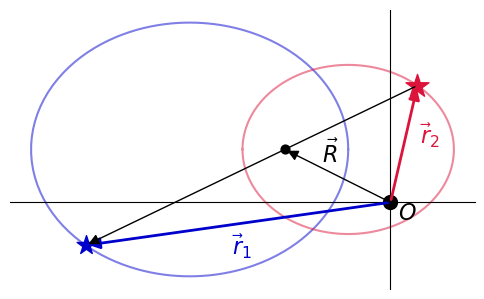

In [32]:
c1 = 'mediumblue'
c2 = 'crimson'

fig, ax = plt.subplots(figsize=(6,6))

# Move the left and bottom "spines" (borders of the plot) to the center
# This makes a math textbook-like set of (x,y) axes instead of a box around the plot
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Take out the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Aspect ratio 1
ax.set_aspect('equal')

# Turn of axis tick marks - we just want to see shapes, not read exact numbers
ax.set_xticks([])
ax.set_yticks([])

# Plot both ellipses
plt.plot(x1ell+xtr, y1ell+ytr, color=c1, alpha=0.5)
plt.plot(x2ell+xtr, y2ell+ytr, color=c2, alpha=0.5)
plt.scatter([x1ex+xtr], [y1ex+ytr], marker='*', color=c1, s=100*m1)
plt.scatter([x2ex+xtr], [y2ex+ytr], marker='*', color=c2, s=100*m2)

# Mark center of mass
ax.scatter([xtr], [ytr], color='k', s=40)

# Mark origin
ax.scatter([0], [0], color='k', s=100)

# Draw arrows
ax.annotate('', xy=(x1ex+xtr, y1ex+ytr), xytext=(0, 0),
            arrowprops=dict(facecolor=c1, edgecolor=c1, arrowstyle='-|>', lw=2))
ax.annotate('', xy=(x2ex+xtr, y2ex+ytr), xytext=(0, 0),
            arrowprops=dict(facecolor=c2, edgecolor=c2, arrowstyle='-|>', lw=2))
ax.annotate('', xy=(x1ex+xtr, y1ex+ytr), xytext=(x2ex+xtr, y2ex+ytr),
            arrowprops=dict(facecolor='k', edgecolor='k', arrowstyle='-|>'))
ax.annotate('', xy=(0, 0), xytext=(xtr, ytr), 
            arrowprops=dict(facecolor='k', edgecolor='k', arrowstyle='<|-'))

# Add text
ax.text(-6, -2, r"$\vec{r}_1$", color=c1)
ax.text(1.1, 2.2, r"$\vec{r}_2$", color=c2)
ax.text(-2.6, 1.5, r"$\vec{R}$", color='k')
ax.text(0.28, -0.65, r"$O$", color='k')

We can always use the Galilean transformation to move into a frame where $\dot{\vec{R}} = 0$, which means $\vec{R}$ becomes an ignorable coordinate and we only have to focus on $\vec{r}$.